<a href="https://colab.research.google.com/github/Ersaoktaviannn/eeg-creative-state-classifier/blob/dev/State_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mne

In [2]:
from google.colab import drive
import os
import numpy as np
import scipy.io
import pywt
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from mne.preprocessing import ICA
from mne.filter import notch_filter, filter_data
from mne import create_info
from mne.io import RawArray
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, LeaveOneGroupOut
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Configuration
warnings.filterwarnings("ignore")
drive.mount('/content/drive')

DATASET_PATH = "/content/drive/MyDrive/Creativity-Dataset"
CHANNEL_NAMES = ['Fp1','Fp2','F3','F4','F7','F8','C3','C4','T3','T4','T5','T6','P3','P4','O1','O2']

# Global EEG Parameters
SFREQ_TARGET = 125
EPOCH_DURATION = 1.0

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
def load_eeg_mat_refined(file_path, selected_channels_idx):
    """Loads EEG data, keeping sub-conditions (IDE, IDG, IDR, RST) separate."""
    mat_data = scipy.io.loadmat(file_path)

    creative_data = {}
    rest_data = {}

    # Identified sub-condition keys
    for k in mat_data.keys():
        if any(sub in k for sub in ['IDE', 'IDG', 'IDR']):
            creative_data[k] = mat_data[k][selected_channels_idx, :]
        elif 'RST' in k:
            rest_data[k] = mat_data[k][selected_channels_idx, :]

    return creative_data, rest_data

In [4]:
def preprocess_eeg(eeg_data, sfreq):
    """Apply notch and bandpass filters, and average re-referencing."""
    eeg_notch = notch_filter(eeg_data, sfreq, freqs=50, verbose=False)
    eeg_filt = filter_data(eeg_notch, sfreq, l_freq=1, h_freq=40, verbose=False)
    eeg_reref = eeg_filt - np.mean(eeg_filt, axis=0)
    return eeg_reref

def remove_artifacts_ica(eeg_data, sfreq, ch_names):
    """Apply Independent Component Analysis for artifact removal."""
    n_channels, n_samples = eeg_data.shape
    info = create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
    raw = RawArray(eeg_data, info, verbose=False)
    ica = ICA(n_components=min(n_channels, 20), random_state=97, max_iter='auto')
    ica.fit(raw, verbose=False)
    # Note: Automatic artifact detection could be added here
    raw_corrected = ica.apply(raw.copy(), verbose=False)
    return raw_corrected.get_data()

In [5]:
def hjorth_params(data):
    """Calculates Activity, Mobility, and Complexity for a 1D signal."""
    # Activity
    activity = np.var(data)

    # Mobility
    d_data = np.diff(data)
    var_d_data = np.var(d_data)
    mobility = np.sqrt(var_d_data / activity) if activity > 0 else 0

    # Complexity
    dd_data = np.diff(d_data)
    var_dd_data = np.var(dd_data)
    mob_d_data = np.sqrt(var_dd_data / var_d_data) if var_d_data > 0 else 0
    complexity = mob_d_data / mobility if mobility > 0 else 0

    return activity, mobility, complexity

In [6]:
def segment_epochs(eeg_data, sfreq, epoch_duration_sec):
    n_channels, n_samples = eeg_data.shape
    samples_per_epoch = int(epoch_duration_sec * sfreq)
    n_epochs = n_samples // samples_per_epoch
    eeg_data = eeg_data[:, :n_epochs * samples_per_epoch]  # potong sisa
    epochs = eeg_data.reshape(n_channels, n_epochs, samples_per_epoch)
    epochs = np.transpose(epochs, (1,0,2))  # bentuk jadi (n_epochs, n_channels, samples_per_epoch)
    return epochs

In [7]:
def extract_dwt_hjorth_features(epoch_data, wavelet='db4', level=5, verbose=False):
    """Extracts Hjorth parameters from DWT Low (cA5) and High (cD1) coefficients."""
    features = []
    if verbose:
        print(f"Extracting DWT features using wavelet: {wavelet}, level: {level}")
        print("Selected coefficients: Low (cA5 - Approximation) and High (cD1 - Detail)")

    for ch_idx, ch_data in enumerate(epoch_data):
        coeffs = pywt.wavedec(ch_data, wavelet, level=level)

        # cA5 is the last level approximation (index 0)
        # cD1 is the first level detail (index -1)
        cA_low = coeffs[0]
        cD_high = coeffs[-1]

        # Hjorth params for Low frequencies
        act_l, mob_l, com_l = hjorth_params(cA_low)
        # Hjorth params for High frequencies
        act_h, mob_h, com_h = hjorth_params(cD_high)

        features.extend([act_l, mob_l, com_l, act_h, mob_h, com_h])

    return np.array(features)

In [8]:
from sklearn.pipeline import Pipeline

def knn_gridsearch_loso(X, y, groups):
    # X shape (n_samples, n_features)
    # groups = subject ids untuk LOSO split

    param_grid = {'knn__n_neighbors': [1,3,5,7]}
    knn = KNeighborsClassifier()
    pipe = Pipeline([('knn', knn)])
    logo = LeaveOneGroupOut()

    accuracies = []
    precisions, recalls, f1s = [], [], []
    conf_matrices = []

    for train_idx, test_idx in logo.split(X, y, groups=groups):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Normalisasi z-score per fitur berdasarkan train
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        gs = GridSearchCV(pipe, param_grid, cv=3)
        gs.fit(X_train, y_train)

        y_pred = gs.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
        cm = confusion_matrix(y_test, y_pred)

        accuracies.append(acc)
        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f1)
        conf_matrices.append(cm)

    print(f'LOSO Accuracy: {np.mean(accuracies):.3f} \u00b1 {np.std(accuracies):.3f}')
    print(f'LOSO Precision: {np.mean(precisions):.3f}')
    print(f'LOSO Recall: {np.mean(recalls):.3f}')
    print(f'LOSO F1-score: {np.mean(f1s):.3f}')

    return accuracies, precisions, recalls, f1s, conf_matrices

In [9]:
def process_subject_data(sid, sfreq, duration, ch_idx=list(range(16))):
    """Helper to load, preprocess, segment and extract features for a single subject."""
    file_path = f"{DATASET_PATH}/Data_Creativity_Sub_{sid}.mat"
    creative_dict, rest_dict = load_eeg_mat_refined(file_path, ch_idx)

    if not creative_dict or not rest_dict:
        return None, None

    # Concatenate sub-conditions
    creative_raw = np.concatenate(list(creative_dict.values()), axis=1)
    rest_raw = np.concatenate(list(rest_dict.values()), axis=1)

    # Preprocess
    cre_clean = preprocess_eeg(creative_raw, sfreq)
    res_clean = preprocess_eeg(rest_raw, sfreq)

    # Segment
    epochs_cre = segment_epochs(cre_clean, sfreq, duration)
    epochs_res = segment_epochs(res_clean, sfreq, duration)

    # Feature Extraction
    feats_cre = np.array([extract_dwt_hjorth_features(e) for e in epochs_cre])
    feats_res = np.array([extract_dwt_hjorth_features(e) for e in epochs_res])

    return feats_cre, feats_res

In [10]:
def process_subject_data(sid, sfreq, duration, ch_idx=list(range(16))):
    """Helper to load, preprocess, segment and extract features for a single subject."""
    file_path = f"{DATASET_PATH}/Data_Creativity_Sub_{sid}.mat"
    creative_dict, rest_dict = load_eeg_mat_refined(file_path, ch_idx)

    if not creative_dict or not rest_dict:
        return None, None

    # Concatenate sub-conditions
    creative_raw = np.concatenate(list(creative_dict.values()), axis=1)
    rest_raw = np.concatenate(list(rest_dict.values()), axis=1)

    # Preprocess
    cre_clean = preprocess_eeg(creative_raw, sfreq)
    res_clean = preprocess_eeg(rest_raw, sfreq)

    # Segment
    epochs_cre = segment_epochs(cre_clean, sfreq, duration)
    epochs_res = segment_epochs(res_clean, sfreq, duration)

    # Feature Extraction
    feats_cre = np.array([extract_dwt_hjorth_features(e) for e in epochs_cre])
    feats_res = np.array([extract_dwt_hjorth_features(e) for e in epochs_res])

    return feats_cre, feats_res

In [11]:
def stat_analysis(features_creative, features_rest):
    """Performs statistical comparison between conditions with Bonferroni correction."""
    from statsmodels.stats.multitest import multipletests
    pvals = []
    n_features = features_creative.shape[1]

    for i in range(n_features):
        data_cre = features_creative[:, i]
        data_res = features_rest[:, i]

        # Normality check (Shapiro-Wilk)
        _, p_norm_cre = shapiro(data_cre)
        _, p_norm_res = shapiro(data_res)

        if p_norm_cre > 0.05 and p_norm_res > 0.05:
            _, p = ttest_ind(data_cre, data_res)
        else:
            _, p = mannwhitneyu(data_cre, data_res, alternative='two-sided')
        pvals.append(p)

    # Vectorized Cohen's d calculation
    mean_cre = np.mean(features_creative, axis=0)
    mean_res = np.mean(features_rest, axis=0)
    var_cre = np.var(features_creative, axis=0, ddof=1)
    var_res = np.var(features_rest, axis=0, ddof=1)
    pooled_std = np.sqrt((var_cre + var_res) / 2)
    effect_sizes = (mean_cre - mean_res) / pooled_std

    # Bonferroni Correction
    reject, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method='bonferroni')

    return pvals, pvals_corrected, effect_sizes, reject

```markdown
### Step 1: Data Loading & Initial Inspection
```

In [12]:
sample_sid = 1
file_path = f"{DATASET_PATH}/Data_Creativity_Sub_{sample_sid}.mat"
creative_dict, rest_dict = load_eeg_mat_refined(file_path, list(range(16)))

print("--- Creative Sub-conditions ---")
for k, v in creative_dict.items():
    print(f"{k}: {v.shape}")

print("\n--- Rest Sub-conditions ---")
for k, v in rest_dict.items():
    print(f"{k}: {v.shape}")

--- Creative Sub-conditions ---
Creativity_1_1_IDE: (16, 27000)
Creativity_1_1_IDG: (16, 15000)
Creativity_1_1_IDR: (16, 12000)
Creativity_1_2_IDE: (16, 31000)
Creativity_1_2_IDG: (16, 7000)
Creativity_1_2_IDR: (16, 5000)
Creativity_1_3_IDE: (16, 31000)
Creativity_1_3_IDG: (16, 6000)
Creativity_1_3_IDR: (16, 4000)

--- Rest Sub-conditions ---
Creativity_1_RST1: (16, 102000)
Creativity_1_RST2: (16, 92000)


```markdown
### Step 2: Preprocessing
```

Cleaned Creative Shape: (16, 138000)
Cleaned Rest Shape: (16, 194000)


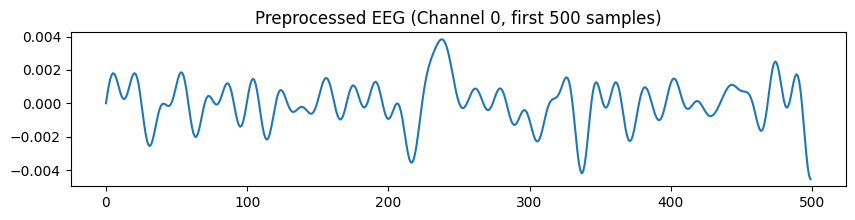

In [13]:
# Handle dictionary input from load_eeg_mat_refined
creative_raw = np.concatenate(list(creative_dict.values()), axis=1)
rest_raw = np.concatenate(list(rest_dict.values()), axis=1)

creative_clean = preprocess_eeg(creative_raw, SFREQ_TARGET)
rest_clean = preprocess_eeg(rest_raw, SFREQ_TARGET)

print(f"Cleaned Creative Shape: {creative_clean.shape}")
print(f"Cleaned Rest Shape: {rest_clean.shape}")

# Visualizing a small segment
plt.figure(figsize=(10, 2))
plt.plot(creative_clean[0, :500])
plt.title("Preprocessed EEG (Channel 0, first 500 samples)")
plt.show()

```markdown
### Step 3: Segmentation
```

In [14]:
epochs_cre = segment_epochs(creative_clean, SFREQ_TARGET, EPOCH_DURATION)
epochs_res = segment_epochs(rest_clean, SFREQ_TARGET, EPOCH_DURATION)

print(f"Creative Epochs: {epochs_cre.shape}") # (n_epochs, n_channels, n_samples)
print(f"Rest Epochs: {epochs_res.shape}")

Creative Epochs: (1104, 16, 125)
Rest Epochs: (1552, 16, 125)


```markdown
### Step 4: Feature Extraction
```

In [15]:
print("Feature Extraction logic check:")
# Run once with verbose output to confirm DWT selection
test_feat = extract_dwt_hjorth_features(epochs_cre[0], verbose=True)

sample_features = np.array([extract_dwt_hjorth_features(e) for e in epochs_cre])
print(f"\nFeature Matrix Shape (Creative): {sample_features.shape}")
display(pd.DataFrame(sample_features).head())

Feature Extraction logic check:
Extracting DWT features using wavelet: db4, level: 5
Selected coefficients: Low (cA5 - Approximation) and High (cD1 - Detail)

Feature Matrix Shape (Creative): (1104, 96)


,0,1,2,3,4,5,6,7,8,9,...,86,87,88,89,90,91,92,93,94,95
0,0.000009,0.654505,2.401286,1.208546e-10,1.299573,1.297335,0.000004,0.864993,1.841922,1.786243e-10,...,1.080911,2.486143e-10,1.697045,1.083036,0.000011,1.261591,1.432393,1.709452e-10,1.220208,1.328044
1,0.000011,1.638068,1.181366,2.876759e-10,1.737362,1.067159,0.000004,1.203871,1.272125,3.760074e-11,...,2.424733,1.563077e-10,1.753424,1.055660,0.000005,1.259599,1.134863,6.673715e-10,1.762875,1.053647
2,0.000011,1.256987,1.246050,7.277795e-10,1.747537,1.058793,0.000010,1.002101,1.938187,4.282299e-10,...,1.614913,5.401650e-11,1.130894,1.409753,0.000013,1.287811,1.371333,6.377555e-10,1.727189,1.068337
3,0.000043,1.187654,0.924750,1.270832e-10,1.453882,1.223419,0.000010,0.891061,1.390890,5.589347e-10,...,0.896365,1.756337e-10,1.688293,1.089271,0.000041,1.104929,1.098004,6.618261e-10,1.735042,1.066611
4,0.000065,0.829367,2.171831,2.601418e-10,1.556265,1.166515,0.000005,1.375162,1.160763,1.830878e-10,...,1.523408,4.153741e-10,1.766289,1.052802,0.000013,0.646227,2.510938,5.884426e-11,1.103336,1.439869


In [16]:
import re

# Memindai folder secara otomatis untuk mendapatkan daftar Subject ID yang tersedia
available_files = os.listdir(DATASET_PATH)
# Mencari pola angka dalam nama file seperti 'Data_Creativity_Sub_1.mat'
subject_files = [f for f in available_files if f.startswith('Data_Creativity_Sub_') and f.endswith('.mat')]
SUBJECT_IDS = sorted([int(re.findall(r'\d+', f)[0]) for f in subject_files])

print(f"Ditemukan {len(SUBJECT_IDS)} subjek di direktori: {SUBJECT_IDS}")

all_features, all_labels, all_groups = [], [], []

print(f"Starting EEG Pipeline for {len(SUBJECT_IDS)} subjects...")
for sid in SUBJECT_IDS:
    print(f"Processing Sub_{sid}...", end=" ")
    try:
        f_cre, f_res = process_subject_data(sid, SFREQ_TARGET, EPOCH_DURATION)
        if f_cre is not None:
            all_features.append(f_cre)
            all_labels.extend([1] * len(f_cre))
            all_features.append(f_res)
            all_labels.extend([0] * len(f_res))
            all_groups.extend([f'Sub_{sid}'] * (len(f_cre) + len(f_res)))
            print("Done.")
    except Exception as e:
        print(f"Failed: {e}")

if all_features:
    X = np.vstack(all_features)
    y = np.array(all_labels)
    groups = np.array(all_groups)

    print(f"\nSummary Statistics:")
    print(f"Total Samples: {X.shape[0]}")
    print(f"Total Features: {X.shape[1]}")

    print("\n LOSO Classification Results ")
    accs, precs, recs, f1s, cms = knn_gridsearch_loso(X, y, groups)

    print("\n Statistical Analysis Results ")
    p_vals, p_corr, d_eff, reject = stat_analysis(X[y == 1], X[y == 0])
    print(f"Significant features (Bonferroni): {np.sum(reject)} / {X.shape[1]}")

    # Identify Top 3 strongest effects
    top_indices = np.argsort(p_corr)[:3]
    print(f"Top 3 Feature Indices: {top_indices}")

Ditemukan 28 subjek di direktori: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
Starting EEG Pipeline for 28 subjects...
Processing Sub_1... Done.
Processing Sub_2... Done.
Processing Sub_3... Done.
Processing Sub_4... Done.
Processing Sub_5... Done.
Processing Sub_6... Done.
Processing Sub_7... Done.
Processing Sub_8... Done.
Processing Sub_9... Done.
Processing Sub_10... Done.
Processing Sub_11... Done.
Processing Sub_12... Done.
Processing Sub_13... Done.
Processing Sub_14... Done.
Processing Sub_15... Done.
Processing Sub_16... Done.
Processing Sub_17... Done.
Processing Sub_18... Done.
Processing Sub_19... Done.
Processing Sub_20... Done.
Processing Sub_21... Done.
Processing Sub_22... Done.
Processing Sub_23... Done.
Processing Sub_24... Done.
Processing Sub_25... Done.
Processing Sub_26... Done.
Processing Sub_27... Done.
Processing Sub_28... Done.

Summary Statistics:
Total Samples: 88880
Total Features: 96

 LOSO Classi

KeyboardInterrupt: 

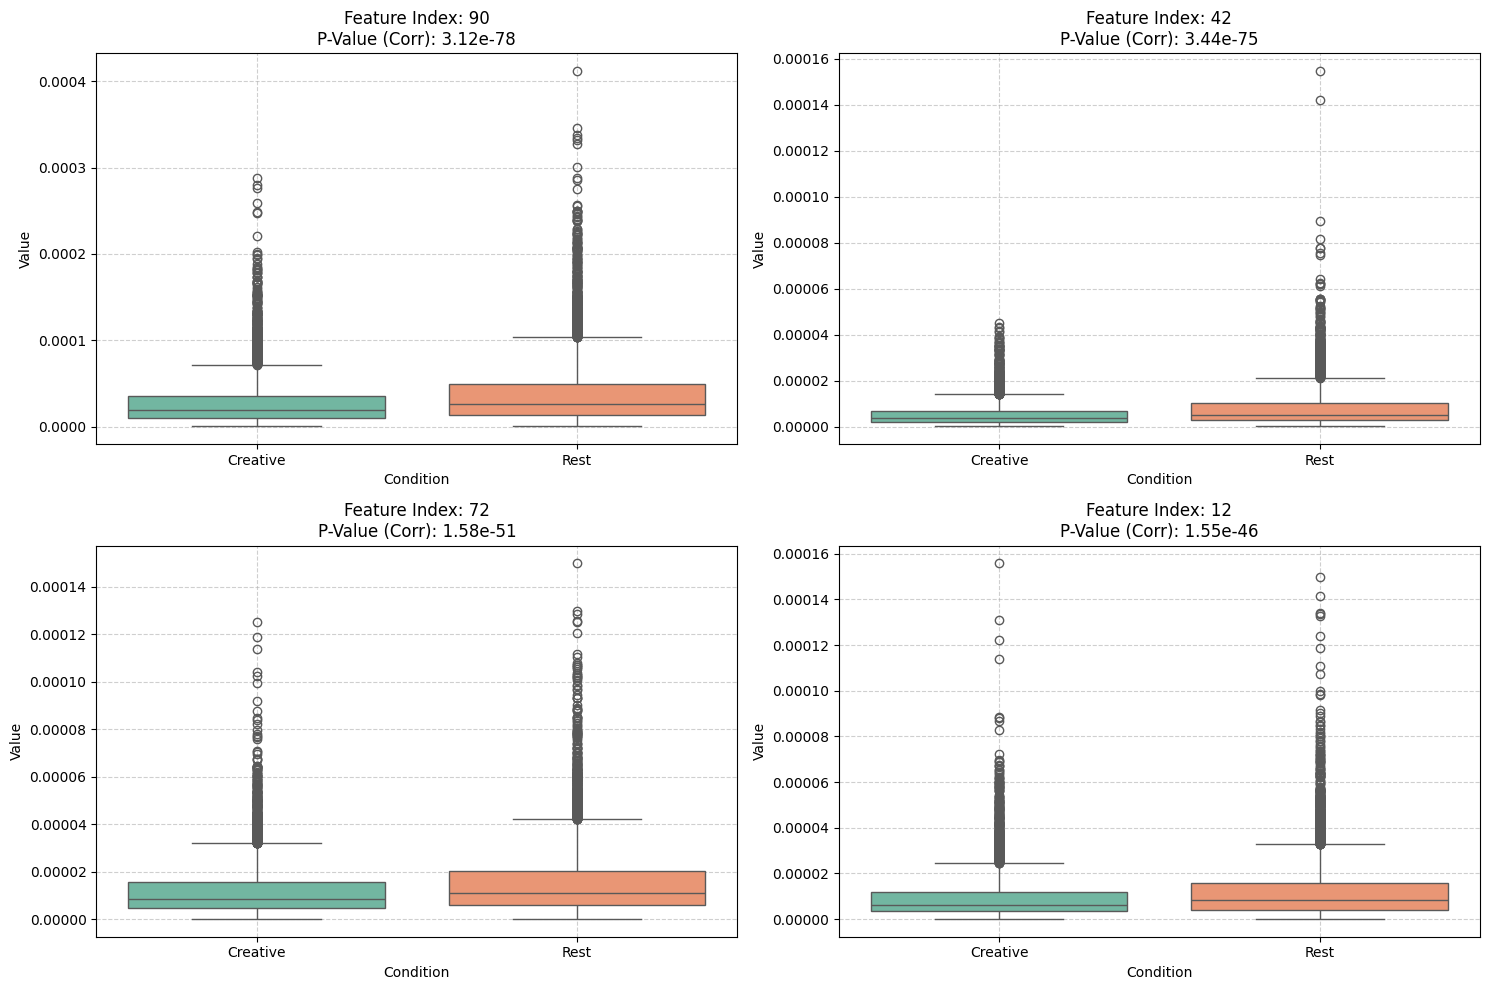

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Find indices of the 4 most significant features (lowest corrected p-values)
sig_indices = np.argsort(p_corr)[:4]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, idx in enumerate(sig_indices):
    # Create a temporary DataFrame for plotting
    df_plot = pd.DataFrame({
        'Value': X[:, idx],
        'Condition': ['Creative' if label == 1 else 'Rest' for label in y]
    })

    sns.boxplot(x='Condition', y='Value', data=df_plot, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Feature Index: {idx}\nP-Value (Corr): {p_corr[idx]:.2e}')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()